<a href="https://colab.research.google.com/github/Ilannahaimenis19/Data-science_Exercises/blob/main/Classificadores_2_Fitness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [163]:
import sklearn as sk
import kagglehub
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np

path = kagglehub.dataset_download("muhammedderric/fitness-classification-dataset-synthetic")

print("Path to dataset files:", path)

df_fitness = pd.read_csv(f'{path}/fitness_dataset.csv')

display(df_fitness)

Path to dataset files: /kaggle/input/fitness-classification-dataset-synthetic


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1
...,...,...,...,...,...,...,...,...,...,...,...
1995,52,173,98,60.7,106.1,NaN,1.54,3.25,1,M,1
1996,61,186,74,51.4,123.8,9.4,8.63,3.15,no,M,1
1997,77,198,89,76.7,103.6,8.3,1.98,3.36,yes,M,0
1998,62,190,63,80.7,115.9,6.7,9.21,2.39,1,F,0


In [164]:

# 1) smokes: no/0 -> 0 | yes/1 -> 1
if 'smokes' in df_fitness.columns:
    df_fitness['smokes'] = (
        df_fitness['smokes']
        .astype(str).str.strip().str.lower()
        .replace({'no': 0, 'yes': 1, '0': 0, '1': 1})
        .astype(int)
    )

# 2) gender: f/F -> 0 | m/M -> 1
if 'gender' in df_fitness.columns:
    df_fitness['gender'] = (
        df_fitness['gender']
        .astype(str).str.strip().str.lower()
        .replace({'f': 0, 'm': 1})
        .astype(int)
    )

display(df_fitness)

/tmp/ipython-input-611183388.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'no': 0, 'yes': 1, '0': 0, '1': 1})
/tmp/ipython-input-611183388.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'f': 0, 'm': 1})


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,0,0,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,0,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,0,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,1,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
1995,52,173,98,60.7,106.1,NaN,1.54,3.25,1,1,1
1996,61,186,74,51.4,123.8,9.4,8.63,3.15,0,1,1
1997,77,198,89,76.7,103.6,8.3,1.98,3.36,1,1,0
1998,62,190,63,80.7,115.9,6.7,9.21,2.39,1,0,0


In [165]:
print("Nulos por coluna (antes):")
print(df_fitness.isnull().sum())

df_fitness['sleep_hours'] = df_fitness['sleep_hours'].fillna(df_fitness['sleep_hours'].median())

print("\nNulos por coluna (depois):")
print(df_fitness.isnull().sum())

Nulos por coluna (antes):
age                    0
height_cm              0
weight_kg              0
heart_rate             0
blood_pressure         0
sleep_hours          160
nutrition_quality      0
activity_index         0
smokes                 0
gender                 0
is_fit                 0
dtype: int64

Nulos por coluna (depois):
age                  0
height_cm            0
weight_kg            0
heart_rate           0
blood_pressure       0
sleep_hours          0
nutrition_quality    0
activity_index       0
smokes               0
gender               0
is_fit               0
dtype: int64


In [166]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Inicializa o scaler
scaler = MinMaxScaler()

# Ajusta e transforma
X_scaled = scaler.fit_transform(X)

# Reconstrói em DataFrame para manter colunas
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())
print("\nResumo estatístico após normalização:")
print(X_scaled.describe())
display(X_scaled)

        age  height_cm  weight_kg  heart_rate  blood_pressure  sleep_hours  \
0  0.622951   0.040816   0.159091    0.334239        0.332512       0.4375   
1  0.836066   0.734694   0.295455    0.214674        0.305419       0.4375   
2  0.459016   0.857143   0.331818    0.222826        0.325123       0.4375   
3  0.229508   0.795918   0.240909    0.206522        0.493842       0.3750   
4  0.688525   0.510204   0.313636    0.177989        0.317734       0.5000   

   nutrition_quality  activity_index  smokes  gender  
0              0.237        0.744361     0.0     0.0  
1              0.877        0.548872     0.0     0.0  
2              0.820        0.258145     0.0     0.0  
3              0.618        0.671679     0.0     1.0  
4              0.995        0.959900     1.0     0.0  

Resumo estatístico após normalização:
               age    height_cm    weight_kg   heart_rate  blood_pressure  \
count  2000.000000  2000.000000  2000.000000  2000.000000     2000.000000   
mean    

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender
0,0.622951,0.040816,0.159091,0.334239,0.332512,0.4375,0.237,0.744361,0.0,0.0
1,0.836066,0.734694,0.295455,0.214674,0.305419,0.4375,0.877,0.548872,0.0,0.0
2,0.459016,0.857143,0.331818,0.222826,0.325123,0.4375,0.820,0.258145,0.0,0.0
3,0.229508,0.795918,0.240909,0.206522,0.493842,0.3750,0.618,0.671679,0.0,1.0
4,0.688525,0.510204,0.313636,0.177989,0.317734,0.5000,0.995,0.959900,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
1995,0.557377,0.469388,0.309091,0.213315,0.198276,0.4375,0.154,0.563910,1.0,1.0
1996,0.704918,0.734694,0.200000,0.086957,0.416256,0.6750,0.863,0.538847,0.0,1.0
1997,0.967213,0.979592,0.268182,0.430707,0.167488,0.5375,0.198,0.591479,1.0,1.0
1998,0.721311,0.816327,0.150000,0.485054,0.318966,0.3375,0.921,0.348371,1.0,0.0


In [167]:
from collections import Counter

X = df_fitness.drop(columns=['is_fit'])
y = df_fitness['is_fit']

print("Distribuição de classes:", Counter(y))

Distribuição de classes: Counter({0: 1201, 1: 799})


In [168]:
from imblearn.over_sampling import SMOTE

# Antes (desbalanceado)
print("Distribuição original:", Counter(y))

# SMOTE (gera amostras sintéticas da classe minoritária)
smote = SMOTE(random_state=42, k_neighbors=5)
X_bal, y_bal = smote.fit_resample(X_scaled, y)

# Depois (balanceado)
print("Distribuição após SMOTE:", Counter(y_bal))
print("Shape X ->", X_scaled.shape, "→", X_bal.shape)

Distribuição original: Counter({0: 1201, 1: 799})
Distribuição após SMOTE: Counter({1: 1201, 0: 1201})
Shape X -> (2000, 10) → (2402, 10)


In [169]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.2, stratify=y_bal, random_state=42
)

print("Tamanho treino:", X_train.shape)
print("Tamanho teste:", X_test.shape)
print("Distribuição treino:", Counter(y_train))
print("Distribuição teste:", Counter(y_test))

Tamanho treino: (1921, 10)
Tamanho teste: (481, 10)
Distribuição treino: Counter({1: 961, 0: 960})
Distribuição teste: Counter({0: 241, 1: 240})


# Logistic Regression

Accuracy: 0.7775467775467776
F1 Score: 0.7774409669930316

Relatório de classificação:
               precision    recall  f1-score   support

           0       0.79      0.76      0.77       241
           1       0.76      0.80      0.78       240

    accuracy                           0.78       481
   macro avg       0.78      0.78      0.78       481
weighted avg       0.78      0.78      0.78       481



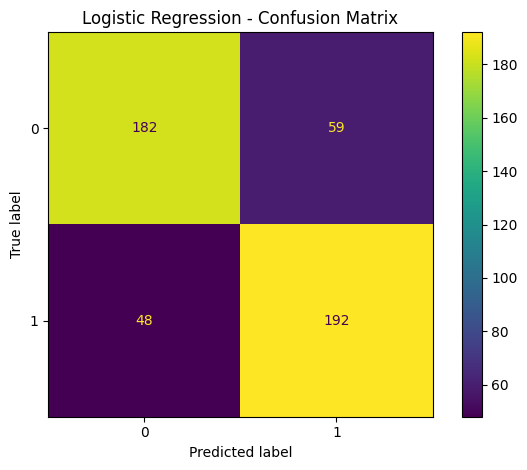

In [170]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="weighted"))
print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()


# KNeighborsClassifier

KNN | Accuracy: 0.735966735966736
KNN | F1 (weighted): 0.7349012587903333

Relatório de classificação (KNN):
               precision    recall  f1-score   support

           0       0.77      0.67      0.72       241
           1       0.71      0.80      0.75       240

    accuracy                           0.74       481
   macro avg       0.74      0.74      0.73       481
weighted avg       0.74      0.74      0.73       481



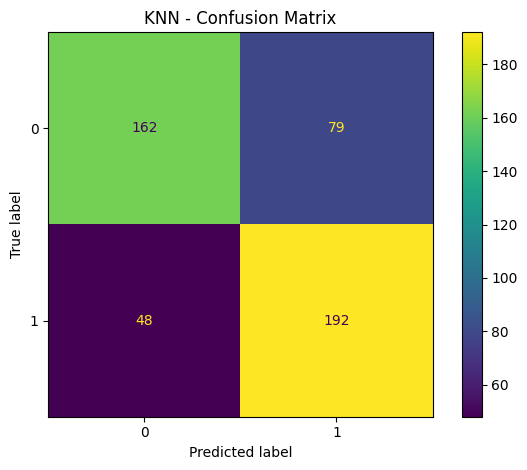

In [171]:
from sklearn.neighbors import KNeighborsClassifier

# Modelo (ajuste n_neighbors se quiser)
knn = KNeighborsClassifier(n_neighbors=5, weights="uniform")
knn.fit(X_train, y_train)

# Predição
y_pred_knn = knn.predict(X_test)

# Métricas
print("KNN | Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN | F1 (weighted):", f1_score(y_test, y_pred_knn, average="weighted"))
print("\nRelatório de classificação (KNN):\n", classification_report(y_test, y_pred_knn))

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# DecisionTreeClassifier

DT  | Accuracy: 0.7422037422037422
DT  | F1 (weighted): 0.7416879710661106

Relatório de classificação (Decision Tree):
               precision    recall  f1-score   support

           0       0.77      0.70      0.73       241
           1       0.72      0.79      0.75       240

    accuracy                           0.74       481
   macro avg       0.74      0.74      0.74       481
weighted avg       0.74      0.74      0.74       481



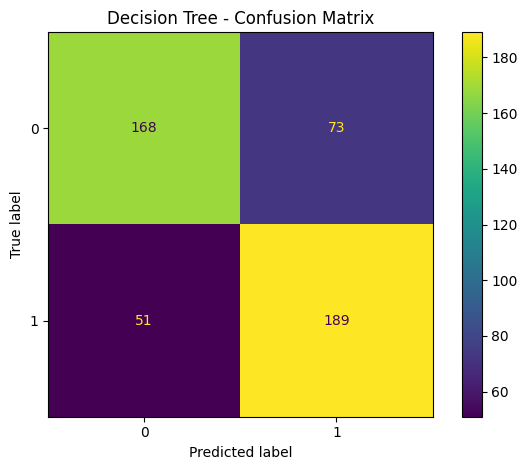

In [172]:
from sklearn.tree import DecisionTreeClassifier

# Modelo (defina profundidade p/ evitar overfitting se necessário)
dt = DecisionTreeClassifier(random_state=42)  # opcional: max_depth=6, min_samples_leaf=5
dt.fit(X_train, y_train)

# Predição
y_pred_dt = dt.predict(X_test)

# Métricas
print("DT  | Accuracy:", accuracy_score(y_test, y_pred_dt))
print("DT  | F1 (weighted):", f1_score(y_test, y_pred_dt, average="weighted"))
print("\nRelatório de classificação (Decision Tree):\n", classification_report(y_test, y_pred_dt))

# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()